In [1]:
using SpeedyWeather, CairoMakie, GLMakie

In [2]:
spectral_grid = SpectralGrid()

SpectralGrid{Spectrum{...}, OctahedralGaussianGrid{...}}
├ Number format: Float32
├ Spectral:      T31 LowerTriangularMatrix
├ Grid:          48-ring OctahedralGaussianGrid, 3168 grid points
├ Resolution:    3.61°, 401km (at 6371km radius)
├ Vertical:      8-layer atmosphere, 2-layer land
└ Architecture:  CPU using Array

In [3]:
model = PrimitiveWetModel(spectral_grid)
simulation = initialize!(model)

Simulation{PrimitiveWetModel}
├ prognostic_variables::PrognosticVariables{...}
├ diagnostic_variables::DiagnosticVariables{...}
└ model::PrimitiveWetModel{...}

## Output variables

In [4]:
model.output

NetCDFOutput{Field{Float32, 1, Vector{Float32}, FullGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
├ status: inactive/uninitialized
├ write restart file: true (if active)
├ interpolator: AnvilInterpolator{Float32, RingGrids.GridGeometry{OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, Vector{Float32}, Vector{Int64}}, RingGrids.AnvilLocator{Float32, Vector{Float32}, Vector{Int64}}}
├ path: output.nc (overwrite=false)
├ frequency: 21600 seconds
└┐ variables:
 ├ v: meridional wind [m/s]
 ├ humid: specific humidity [kg/kg]
 ├ temp: temperature [degC]
 ├ u: zonal wind [m/s]
 ├ mslp: mean sea-level pressure [hPa]
 └ vor: relative vorticity [s^-1]

In [5]:
add!(model, SpeedyWeather.RadiationOutput()...)

NetCDFOutput{Field{Float32, 1, Vector{Float32}, FullGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
├ status: inactive/uninitialized
├ write restart file: true (if active)
├ interpolator: AnvilInterpolator{Float32, RingGrids.GridGeometry{OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, Vector{Float32}, Vector{Int64}}, RingGrids.AnvilLocator{Float32, Vector{Float32}, Vector{Int64}}}
├ path: output.nc (overwrite=false)
├ frequency: 21600 seconds
└┐ variables:
 ├ sru: Surface shortwave radiation up [W/m^2]
 ├ temp: temperature [degC]
 ├ srd: Surface shortwave radiation down [W/m^2]
 ├ mslp: mean sea-level pressure [hPa]
 ├ vor: relative vorticity [s^-1]
 ├ osr: Outgoing shortwave radiation [W/m^2]
 ├ v: meridional wind [m/s]
 ├ u: zonal wind [m/s]
 ├ albedo: albedo [1]
 ├ lrd: Surface longwave radiation down [W/m^2]
 ├ humid: specific humidity [kg/kg]
 ├ olr: Outgoing longwave radiation [W/m^2]
 └ lru: Surfa

In [6]:
add!(model, SpeedyWeather.SurfaceFluxesOutput()...)

NetCDFOutput{Field{Float32, 1, Vector{Float32}, FullGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
├ status: inactive/uninitialized
├ write restart file: true (if active)
├ interpolator: AnvilInterpolator{Float32, RingGrids.GridGeometry{OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, Vector{Float32}, Vector{Int64}}, RingGrids.AnvilLocator{Float32, Vector{Float32}, Vector{Int64}}}
├ path: output.nc (overwrite=false)
├ frequency: 21600 seconds
└┐ variables:
 ├ slf: Surface latent heat flux (positive up) [W/m^2]
 ├ sru: Surface shortwave radiation up [W/m^2]
 ├ temp: temperature [degC]
 ├ srd: Surface shortwave radiation down [W/m^2]
 ├ mslp: mean sea-level pressure [hPa]
 ├ vor: relative vorticity [s^-1]
 ├ osr: Outgoing shortwave radiation [W/m^2]
 ├ v: meridional wind [m/s]
 ├ u: zonal wind [m/s]
 ├ albedo: albedo [1]
 ├ lrd: Surface longwave radiation down [W/m^2]
 ├ shf: Surface sensible heat flux (po

In [7]:
simulation.diagnostic_variables.physics.sensible_heat_flux

3168-element, 48-ring OctahedralGaussianField{Float32, 1} as Array on CPU
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 ⋮
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0

In [8]:
simulation.diagnostic_variables.physics.surface_latent_heat_flux

3168-element, 48-ring OctahedralGaussianField{Float32, 1} as Array on CPU
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 ⋮
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0
 0.0f0

In [9]:
# run!(simulation, period=Day(30))
run!(simulation, period=Day(365))

Weather is speedy: 100%|██████████████████| Time: 0:01:51 (776.41 years/day)/day)765.16 years/day)█████████████|  ETA: 0:00:01 (776.21 years/day)


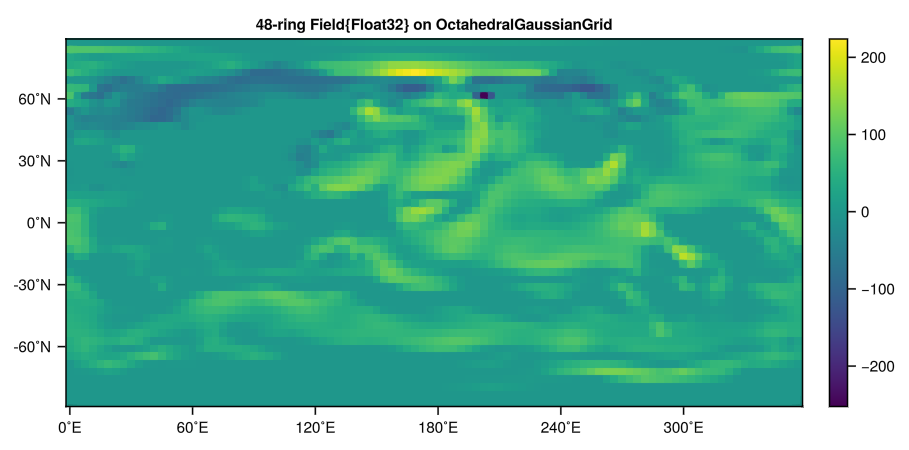

In [10]:
heatmap(simulation.diagnostic_variables.physics.sensible_heat_flux)

In [11]:
simulation.prognostic_variables.clock

Clock
├ time::DateTime = 2000-12-31T00:00:00
├ start::DateTime = 2000-01-01T00:00:00
├ period::Second = 31536000 seconds
├ timestep_counter::Int64 = 13140
├ n_timesteps::Int64 = 13140
└ Δt::Millisecond = 2400000 milliseconds

In [12]:
function calc_global_sum(field, model)
    a00 = real(transform(field)[1])
    mean_per_m2 = a00 / model.spectral_transform.norm_sphere
    total_W = mean_per_m2 * (4*pi*model.planet.radius^2)
    return total_W
end


calc_global_sum (generic function with 1 method)

In [13]:
function calc_global_mean(field, model)
    a00 = real(transform(field)[1])
    return a00 / model.spectral_transform.norm_sphere    
end
# mean_per_m2 = a00 / model.spectral_transform.norm_sphere

calc_global_mean (generic function with 1 method)

In [14]:
mean_SHF = calc_global_mean(simulation.diagnostic_variables.physics.sensible_heat_flux, model)

27.636118f0

In [15]:
mean_LHF = calc_global_mean(simulation.diagnostic_variables.physics.surface_latent_heat_flux, model)

43.161327f0

In [16]:
simulation.diagnostic_variables.physics

PhysicsVariables
├ grid: OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}
├ ocean: DynamicsVariablesOcean{Float32, Array, OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, Field{Float32, 1, Vector{Float32}, OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
├ land: DynamicsVariablesLand{Float32, Array, OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, Field{Float32, 1, Vector{Float32}, OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
├ rain_large_scale: 3168-element, 48-ring Field{Float32}
├ rain_convection: 3168-element, 48-ring Field{Float32}
├ snow_large_scale: 3168-element, 48-ring Field{Float32}
├ snow_convection: 3168-element, 48-ring Field{Float32}
├ total_precipitation_rate: 3168-element, 48-ring Field{Float32}
├ cloud_top: 3168-element, 48-ring Field{Float32}

In [17]:
function calc_trenberth_variables(simulation, model; SumFlag::Bool=false)
    # this is a function to calculate the variables we need to plot the Trenberth diagram.
    # simulation -> the SpeedyWeather simulation output.
    # model -> the SpeedyWeather model structure.
    # SumFlag -> false for clculating using the area mean of the fluxes [W/m^2] and true for calculating for the global sum [W]. 

        # put all fields in a Dict
    fields = Dict(
        :LHF   => simulation.diagnostic_variables.physics.surface_latent_heat_flux,
        :SHF   => simulation.diagnostic_variables.physics.sensible_heat_flux,
        :SSRU  => simulation.diagnostic_variables.physics.surface_shortwave_up,
        :SLRU  => simulation.diagnostic_variables.physics.surface_longwave_up,
        :SSRD  => simulation.diagnostic_variables.physics.surface_shortwave_down,
        :SLRD  => simulation.diagnostic_variables.physics.surface_longwave_down,
        :OSR   => simulation.diagnostic_variables.physics.outgoing_shortwave_radiation,
        :OLR   => simulation.diagnostic_variables.physics.outgoing_longwave_radiation,
        :albedo => simulation.diagnostic_variables.physics.albedo
    )

    # initialize result container
    results = Dict{Symbol, Float64}()

    # pick the function once
    calcfun = SumFlag ? calc_global_sum : calc_global_mean

    for (name, field) in fields
        try
            results[name] = calcfun(field, model)
        catch err
            # more informative error handling
            @warn "Could not compute $name: $err"
            results[name] = NaN
        end
    end

    # optional derived Trenberth terms (example: ASR, surface net radiation)
    # note: sign conventions may vary in your model; adapt as needed
    # ASR (absorbed shortwave at TOA) = incoming_TOA - reflected_TOA
    # If you only have OSR as outgoing shortwave at TOA, and you know S_in_TOA:
    # results[:ASR] = S_in_global_total - results[:OSR]  # only if you have S_in_TOA
    
    # Simple surface net (down - up) :
    results[:SW_net_sfc] = results[:SSRD] - results[:SSRU]    # W/m2 or W
    results[:LW_net_sfc] = results[:SLRD] - results[:SLRU]
    results[:surface_net]  = results[:SW_net_sfc] + results[:LW_net_sfc] - results[:LHF] - results[:SHF]

    return results

    return results
end


calc_trenberth_variables (generic function with 1 method)

In [18]:
R_mean = calc_trenberth_variables(simulation, model; SumFlag=false)  # global means

Dict{Symbol, Float64} with 12 entries:
  :LW_net_sfc  => -237.881
  :OLR         => 301.847
  :SSRD        => 341.257
  :SLRD        => 0.0
  :SHF         => 27.6361
  :SSRU        => 27.2284
  :SLRU        => 237.881
  :LHF         => 43.1613
  :albedo      => 0.116091
  :SW_net_sfc  => 314.029
  :OSR         => 27.2284
  :surface_net => 5.35018

#### adding callbacks: 

In [19]:
# --------------------------
# helper: compute Trenberth diagnostics from diagn + model
# --------------------------
function calc_trenberth_from_diagn(diagn, model; SumFlag::Bool=false)
    fields = Dict(
        :LHF   => diagn.physics.surface_latent_heat_flux,
        :SHF   => diagn.physics.sensible_heat_flux,
        :SSRU  => diagn.physics.surface_shortwave_up,
        :SLRU  => diagn.physics.surface_longwave_up,
        :SSRD  => diagn.physics.surface_shortwave_down,
        :SLRD  => diagn.physics.surface_longwave_down,
        :OSR   => diagn.physics.outgoing_shortwave_radiation,
        :OLR   => diagn.physics.outgoing_longwave_radiation,
        :albedo=> diagn.physics.albedo
    )

    # spectral helpers (ℓ=0 → global mean; multiply by area for total)
    function calc_global_mean(field)
        a = transform(field)              # model transform -> spectral coeffs
        a00 = real(a[1])                  # index 1 == ℓ=0,m=0 (SpeedyWeather layout)
        return a00 / model.spectral_transform.norm_sphere
    end
    function calc_global_sum(field)
        mean_val = calc_global_mean(field)
        area = 4π * model.planet.radius^2
        return mean_val * area
    end

    calcfun = SumFlag ? calc_global_sum : calc_global_mean

    results = Dict{Symbol, Float64}()
    for (k, f) in fields
        try
            results[k] = Float64(calcfun(f))
        catch err
            @warn "calc_trenberth_from_diagn: could not compute $k: $err"
            results[k] = NaN
        end
    end

    # derived surface/Trenberth terms (adjust sign convention as needed)
    results[:SW_net_sfc]  = results[:SSRD] - results[:SSRU]
    results[:LW_net_sfc]  = results[:SLRD] - results[:SLRU]
    results[:surface_net] = results[:SW_net_sfc] + results[:LW_net_sfc] - results[:LHF] - results[:SHF]

    return results
end


calc_trenberth_from_diagn (generic function with 1 method)

In [20]:
# --- callback type ---
# Base.@kwdef mutable struct TrenberthCallback <: SpeedyWeather.AbstractCallback
#     timestep_counter::Int = 0
#     data::Dict{Symbol, Vector{Float64}} = Dict{Symbol, Vector{Float64}}()
#     times::Vector{Float64} = Float64[]  # elapsed seconds since simulation start
#     datetimes::Vector{DateTime} = DateTime[]  # corresponding DateTime objects
#     start_time::Float64 = 0.0  # simulation start time in seconds
#     SumFlag::Bool = false
# end

In [21]:
Base.@kwdef mutable struct TrenberthCallback <: SpeedyWeather.AbstractCallback
    timestep_counter::Int = 0
    data::Dict{Symbol, Vector{Float64}} = Dict{Symbol, Vector{Float64}}()
    times::Vector{Float64} = Float64[]          # elapsed seconds
    datetimes::Vector{DateTime} = DateTime[]    # original DateTime stamps
    start_time::Float64 = 0.0
    SumFlag::Bool = false
    var_longnames::Dict{Symbol,String} = TRENBERTH_LONGNAMES
end

TrenberthCallback

In [22]:
# Default long names for Trenberth variables
const TRENBERTH_LONGNAMES = Dict(
    :LHF => "Surface latent heat flux (W/m²)",
    :SHF => "Surface sensible heat flux (W/m²)",
    :SSRU => "Surface shortwave up (W/m²)",
    :SLRU => "Surface longwave up (W/m²)",
    :SSRD => "Surface shortwave down (W/m²)",
    :SLRD => "Surface longwave down (W/m²)",
    :OSR => "Outgoing shortwave radiation (TOA) (W/m²)",
    :OLR => "Outgoing longwave radiation (TOA) (W/m²)",
    :albedo => "Surface albedo",
    :SW_net_sfc => "Surface net shortwave (W/m²)",
    :LW_net_sfc => "Surface net longwave (W/m²)",
    :surface_net => "Surface net energy (W/m²)"
)

Dict{Symbol, String} with 12 entries:
  :surface_net => "Surface net energy (W/m²)"
  :SLRU        => "Surface longwave up (W/m²)"
  :LHF         => "Surface latent heat flux (W/m²)"
  :LW_net_sfc  => "Surface net longwave (W/m²)"
  :OLR         => "Outgoing longwave radiation (TOA) (W/m²)"
  :albedo      => "Surface albedo"
  :SSRD        => "Surface shortwave down (W/m²)"
  :SW_net_sfc  => "Surface net shortwave (W/m²)"
  :OSR         => "Outgoing shortwave radiation (TOA) (W/m²)"
  :SLRD        => "Surface longwave down (W/m²)"
  :SHF         => "Surface sensible heat flux (W/m²)"
  :SSRU        => "Surface shortwave up (W/m²)"

In [23]:
function TrenberthCallback(; vars = [:LHF,:SHF,:SSRU,:SLRU,:SSRD,:SLRD,:OSR,:OLR,:albedo,:SW_net_sfc,:LW_net_sfc,:surface_net],
                             SumFlag::Bool=false,
                             nsteps::Int=0,
                             var_longnames::Dict{Symbol,String}=TRENBERTH_LONGNAMES)
    d = Dict{Symbol, Vector{Float64}}()
    for v in vars
        d[v] = nsteps > 0 ? Vector{Float64}(undef, nsteps + 1) : Float64[]
    end
    times = nsteps > 0 ? Vector{Float64}(undef, nsteps + 1) : Float64[]
    datetimes = nsteps > 0 ? Vector{DateTime}(undef, nsteps + 1) : DateTime[]
    return TrenberthCallback(0, d, times, datetimes, 0.0, SumFlag, var_longnames)
end

TrenberthCallback

In [24]:
# Pretty-print the long names
function show_var_names(cb::TrenberthCallback)
    for (k, long) in cb.var_longnames
        println(string(k), " → ", long)
    end
    return nothing
end

# Optional: assemble a DataFrame if DataFrames.jl is installed
function to_dataframe(cb::TrenberthCallback)
    try
        @eval using DataFrames
    catch
        error("DataFrames.jl not available. Install it with `using Pkg; Pkg.add(\"DataFrames\")`")
    end
    df = DataFrame(time = cb.datetimes)
    for (k, vec) in cb.data
        colname = get(cb.var_longnames, k, string(k))  # column name uses long name if available
        # ensure column identifier is a Symbol
        df[Symbol(colname)] = vec
    end
    return df
end

to_dataframe (generic function with 1 method)

In [25]:
using Dates

# Convert various time types to Float64. Default unit = :seconds.
function time_to_float(t; unit::Symbol = :seconds)
    if t isa DateTime
        secs = Dates.datetime2unix(t)                     # seconds since Unix epoch
        return unit == :seconds ? Float64(secs) :
               unit == :days    ? Float64(secs / 86400.0) :
               error("unsupported unit: $unit")
    elseif t <: Dates.Period   # Day, Hour, Minute, etc.
        # Dates.value returns the integer magnitude in the Period's base units
        # For Day it returns number of days, for Hour number of hours, etc.
        # Convert to days or seconds depending on unit
        if unit == :days
            return float(Dates.value(t))
        elseif unit == :seconds
            # approximate: convert days/hours etc. to seconds using common ratios
            # We'll convert via Day/Hr/Minute explicitly for safety:
            if t isa Day
                return float(Dates.value(t) * 86400)
            elseif t isa Hour
                return float(Dates.value(t) * 3600)
            elseif t isa Minute
                return float(Dates.value(t) * 60)
            else
                # fallback: convert to days then seconds
                return float(Dates.value(Day(round(Int, Dates.value(t)))) * 86400)
            end
        else
            error("unsupported unit: $unit")
        end
    elseif t isa Number
        return float(t)
    else
        error("unsupported time type: $(typeof(t))")
    end
end


time_to_float (generic function with 1 method)

In [26]:
function SpeedyWeather.initialize!(cb::TrenberthCallback,
                                   progn::PrognosticVariables,
                                   diagn::DiagnosticVariables,
                                   model::AbstractModel)
    # Store the simulation start time for reference (convert DateTime to Float64 Unix timestamp)
    cb.start_time = Dates.datetime2unix(progn.clock.time)
    
    # Try to get nsteps, but if it doesn't work, just start with empty vectors
    try
        nsteps = progn.clock.nsteps
        # if our data dict vectors are empty or wrong size, (re)allocate
        for (k, v) in cb.data
            if isempty(v) || length(v) != nsteps + 1
                cb.data[k] = Vector{Float64}(undef, nsteps + 1)
            end
        end
        if isempty(cb.times) || length(cb.times) != nsteps + 1
            cb.times = Vector{Float64}(undef, nsteps + 1)
        end
        if isempty(cb.datetimes) || length(cb.datetimes) != nsteps + 1
            cb.datetimes = Vector{DateTime}(undef, nsteps + 1)
        end
    catch
        # If we can't get nsteps, just use dynamic push mode
        @info "Could not determine nsteps, using dynamic push mode"
    end

    # set counter to 1 and store initial conditions
    cb.timestep_counter = 1
    t0 = Dates.datetime2unix(progn.clock.time)  # Convert DateTime to Unix timestamp
    dt0 = progn.clock.time  # Get the original DateTime object
    # compute initial values using diagn
    res0 = calc_trenberth_from_diagn(diagn, model; SumFlag=cb.SumFlag)
    for (k, v) in res0
        if haskey(cb.data, k)
            if length(cb.data[k]) > 0
                cb.data[k][1] = v
            else
                push!(cb.data[k], v)
            end
        else
            cb.data[k] = [v]
        end
    end

    # Store time relative to simulation start (in seconds) and DateTime
    if length(cb.times) > 0
        cb.times[1] = t0 - cb.start_time
        cb.datetimes[1] = dt0
    else
        push!(cb.times, t0 - cb.start_time)
        push!(cb.datetimes, dt0)
    end
    return nothing
end

In [27]:
# --- callback! called every step (after the step completes) ---
function SpeedyWeather.callback!(cb::TrenberthCallback,
                                 progn::PrognosticVariables,
                                 diagn::DiagnosticVariables,
                                 model::AbstractModel)
    # increment step index
    cb.timestep_counter += 1
    
    # compute current diagnostics
    res = calc_trenberth_from_diagn(diagn, model; SumFlag=cb.SumFlag)
    
    # push new values to the arrays
    for (k, v) in res
        if !haskey(cb.data, k)
            # new key appeared: create vector and push
            cb.data[k] = [v]
        else
            # existing key: push to the vector
            push!(cb.data[k], v)
        end
    end
    
    # record model time relative to simulation start (in seconds) and DateTime
    # Convert DateTime to Unix timestamp, then subtract start_time to get elapsed seconds
    current_time = Dates.datetime2unix(progn.clock.time)
    push!(cb.times, current_time - cb.start_time)
    push!(cb.datetimes, progn.clock.time)  # Store the DateTime object
    return nothing
end

In [28]:
# --- finalize (optional) ---
SpeedyWeather.finalize!(cb::TrenberthCallback, args...) = nothing

adding the calbak to the model


In [29]:
# preallocated (fast) if you know nsteps:
# cb = TrenberthCallback(SumFlag=false, grow=false, nsteps=1000)

# OR dynamic push mode (flexible):
cb = TrenberthCallback(SumFlag=false,  nsteps=0)


TrenberthCallback <: AbstractCallback
├ timestep_counter::Int64 = 0
├ data::Dict{Symbol, Vector{Float64}} = Dict(:LW_net_sfc => [], :OLR => [], :SSRD => [], :SLRD => [], :SHF => [], :SSRU => [], :SLRU => [], :LHF => [], :albedo => [], :SW_net_sfc => [], :OSR => [], :surface_net => [])
├ start_time::Float64 = 0.0
├ SumFlag::Bool = false
├ var_longnames::Dict{Symbol, String} = Dict(:surface_net => "Surface net energy (W/m²)", :SLRU => "Surface longwave up (W/m²)", :LHF => "Surface latent heat flux (W/m²)", :LW_net_sfc => "Surface net longwave (W/m²)", :OLR => "Outgoing longwave radiation (TOA) (W/m²)", :albedo => "Surface albedo", :SSRD => "Surface shortwave down (W/m²)", :SW_net_sfc => "Surface net shortwave (W/m²)", :OSR => "Outgoing shortwave radiation (TOA) (W/m²)", :SLRD => "Surface longwave down (W/m²)", :SHF => "Surface sensible heat flux (W/m²)", :SSRU => "Surface shortwave up (W/m²)")
└── arrays: times, datetimes

In [30]:
# A: add into the callbacks dict directly (works if model.callbacks is a Dict-like)
add!(model.callbacks, :trenberth => cb)

In [ ]:
keys(model.callbacks)              # should include :trenberth to make sure the callback was added correctly.

KeySet for a Dict{Symbol, SpeedyWeather.AbstractCallback} with 1 entry. Keys:
  :trenberth

In [ ]:
model.callbacks[:trenberth] === cb # should be true to make sure the callback was added correctly. 

true

In [32]:
sim = initialize!(model)   # this will call SpeedyWeather.initialize! on cb
run!(sim, period=Day(10))  # or your usual run invocation

[ Info: Could not determine nsteps, using dynamic push mode
Weather is speedy: 100%|██████████████████| Time: 0:00:10 (226.43 years/day)


In [33]:
cb.data

Dict{Symbol, Vector{Float64}} with 12 entries:
  :LW_net_sfc  => [0.0, -239.742, -238.96, -238.311, -237.911, -237.739, -237.8…
  :OLR         => [0.0, 357.659, 352.521, 350.784, 346.932, 343.66, 342.421, 34…
  :SSRD        => [0.0, 341.258, 341.252, 341.259, 341.256, 341.267, 341.243, 3…
  :SLRD        => [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.…
  :SHF         => [0.0, 20.9445, 25.3991, 22.7005, 19.4452, 19.1563, 15.0698, 1…
  :SSRU        => [0.0, 28.0432, 28.3989, 29.1781, 30.0129, 30.8464, 31.6498, 3…
  :SLRU        => [0.0, 239.742, 238.96, 238.311, 237.911, 237.739, 237.803, 23…
  :LHF         => [0.0, 14.0758, 14.1463, 15.1494, 14.0292, 12.547, 9.97612, 7.…
  :albedo      => [0.0, 0.115173, 0.115173, 0.115173, 0.115173, 0.115173, 0.115…
  :SW_net_sfc  => [0.0, 313.214, 312.853, 312.081, 311.243, 310.421, 309.593, 3…
  :OSR         => [0.0, 28.0432, 28.3989, 29.1781, 30.0129, 30.8464, 31.6498, 3…
  :surface_net => [0.0, 38.4521, 34.3478, 35.9207, 39.8579, 40

In [34]:
cb.times

361-element Vector{Float64}:
      0.0
   2400.0
   4800.0
   7200.0
   9600.0
  12000.0
  14400.0
  16800.0
  19200.0
  21600.0
  24000.0
  26400.0
  28800.0
      ⋮
 837600.0
 840000.0
 842400.0
 844800.0
 847200.0
 849600.0
 852000.0
 854400.0
 856800.0
 859200.0
 861600.0
 864000.0

In [35]:
cb.datetimes

361-element Vector{DateTime}:
 2000-01-01T00:00:00
 2000-01-01T00:40:00
 2000-01-01T01:20:00
 2000-01-01T02:00:00
 2000-01-01T02:40:00
 2000-01-01T03:20:00
 2000-01-01T04:00:00
 2000-01-01T04:40:00
 2000-01-01T05:20:00
 2000-01-01T06:00:00
 2000-01-01T06:40:00
 2000-01-01T07:20:00
 2000-01-01T08:00:00
 ⋮
 2000-01-10T16:40:00
 2000-01-10T17:20:00
 2000-01-10T18:00:00
 2000-01-10T18:40:00
 2000-01-10T19:20:00
 2000-01-10T20:00:00
 2000-01-10T20:40:00
 2000-01-10T21:20:00
 2000-01-10T22:00:00
 2000-01-10T22:40:00
 2000-01-10T23:20:00
 2000-01-11T00:00:00

In [36]:
cb.var_longnames

Dict{Symbol, String} with 12 entries:
  :surface_net => "Surface net energy (W/m²)"
  :SLRU        => "Surface longwave up (W/m²)"
  :LHF         => "Surface latent heat flux (W/m²)"
  :LW_net_sfc  => "Surface net longwave (W/m²)"
  :OLR         => "Outgoing longwave radiation (TOA) (W/m²)"
  :albedo      => "Surface albedo"
  :SSRD        => "Surface shortwave down (W/m²)"
  :SW_net_sfc  => "Surface net shortwave (W/m²)"
  :OSR         => "Outgoing shortwave radiation (TOA) (W/m²)"
  :SLRD        => "Surface longwave down (W/m²)"
  :SHF         => "Surface sensible heat flux (W/m²)"
  :SSRU        => "Surface shortwave up (W/m²)"

In [37]:
# # --- callback! called every step (after the step completes) ---
# function SpeedyWeather.callback!(cb::TrenberthCallback,
#                                  progn::PrognosticVariables,
#                                  diagn::DiagnosticVariables,
#                                  model::AbstractModel)
#     # increment step index
#     cb.timestep_counter += 1
#     i = cb.timestep_counter
#     # compute current diagnostics
#     res = calc_trenberth_from_diagn(diagn, model; SumFlag=cb.SumFlag)
#     # store them into preallocated arrays (assumes cb.data already has keys)
#     for (k, v) in res
#         if !haskey(cb.data, k)
#             # if a new key appears, create and fill (resize existing to fit previous slots)
#             oldlen = i - 1
#             newvec = Vector{Float64}(undef, length(cb.times))
#             fill!(newvec, NaN)
#             newvec[i] = v
#             cb.data[k] = newvec
#         else
#             cb.data[k][i] = v
#         end
#     end
#     # record model time
#     cb.times[i] = float(progn.clock.current_time)
#     return nothing
# end

In [38]:
# # --- initialize! called once before run (populate sizes and initial state) ---
# function SpeedyWeather.initialize!(cb::TrenberthCallback,
#                                    progn::PrognosticVariables,
#                                    diagn::DiagnosticVariables,
#                                    model::AbstractModel)
#     # Try to get nsteps, but if it doesn't work, just start with empty vectors
#     try
#         nsteps = progn.clock.nsteps
#         # if our data dict vectors are empty or wrong size, (re)allocate
#         for (k, v) in cb.data
#             if isempty(v) || length(v) != nsteps + 1
#                 cb.data[k] = Vector{Float64}(undef, nsteps + 1)
#             end
#         end
#         if isempty(cb.times) || length(cb.times) != nsteps + 1
#             cb.times = Vector{Float64}(undef, nsteps + 1)
#         end
#     catch
#         # If we can't get nsteps, just use dynamic push mode
#         @info "Could not determine nsteps, using dynamic push mode"
#     end

#     # set counter to 1 and store initial conditions
#     cb.timestep_counter = 1
#     t0 = progn.clock.time
#     # compute initial values using diagn
#     res0 = calc_trenberth_from_diagn(diagn, model; SumFlag=cb.SumFlag)
#     for (k, v) in res0
#         if haskey(cb.data, k)
#             if length(cb.data[k]) > 0
#                 cb.data[k][1] = v
#             else
#                 push!(cb.data[k], v)
#             end
#         else
#             cb.data[k] = [v]
#         end
#     end
#     if length(cb.times) > 0
#         cb.times[1] = time_to_float(t0)
#     else
#         push!(cb.times, float(t0))
#     end
#     return nothing
# end

In [39]:
# convenience generator: create a recorder pre-filled with keys and preallocated arrays
# function TrenberthCallback(;vars = [:LHF,:SHF,:SSRU,:SLRU,:SSRD,:SLRD,:OSR,:OLR,:albedo,:SW_net_sfc,:LW_net_sfc,:surface_net],
#                              SumFlag::Bool=false,
#                              nsteps::Int=0)
#     d = Dict{Symbol, Vector{Float64}}()
#     # pre-allocate vectors length nsteps+1 if nsteps>0, otherwise empty and will push
#     for v in vars
#         d[v] = nsteps > 0 ? Vector{Float64}(undef, nsteps + 1) : Float64[]
#     end
#     times = nsteps > 0 ? Vector{Float64}(undef, nsteps + 1) : Float64[]
#     datetimes = nsteps > 0 ? Vector{DateTime}(undef, nsteps + 1) : DateTime[]
#     return TrenberthCallback(0, d, times, datetimes, 0.0, SumFlag)
# end